In [21]:
import pandas as pd

url = "https://raw.githubusercontent.com/Asif117204/220128_Asif_DT-and-K-Means/main/weather_forecast_data.csv"

df = pd.read_csv(url)

print(df.head())

   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [23]:
print(df.shape)

df.info()

df.isnull().sum()

(2500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


,0
Temperature,0
Humidity,0
Wind_Speed,0
Cloud_Cover,0
Pressure,0
Rain,0


In [24]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[num_cols] = num_imputer.fit_transform(df[num_cols])

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind_Speed,0
Cloud_Cover,0
Pressure,0
Rain,0


In [25]:
label_encoders = {}

for col in cat_cols:
    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col])

    label_encoders[col] = encoder

df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,0


In [26]:
target = df.columns[-1]

X = df.drop(columns=[target])

y = df[target]

print(X.shape)

print(y.shape)

(2500, 5)
(2500,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
cart_parameters = {
    "max_depth":[2,3,4,5,6,8,10],
    "min_samples_split":[2,5,10,15]
}

cart_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ),
    cart_parameters,
    cv=5,
    scoring="accuracy"
)

cart_grid.fit(X_train_scaled,y_train)

best_cart = cart_grid.best_estimator_

print(cart_grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [30]:
id3_parameters = {
    "max_depth":[2,3,4,5,6,8,10],
    "min_samples_split":[2,5,10,15]
}

id3_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    id3_parameters,
    cv=5,
    scoring="accuracy"
)

id3_grid.fit(X_train_scaled,y_train)

best_id3 = id3_grid.best_estimator_

print(id3_grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [31]:
cart_pred = best_cart.predict(X_test_scaled)

id3_pred = best_id3.predict(X_test_scaled)

cart_prob = best_cart.predict_proba(X_test_scaled)[:,1]

id3_prob = best_id3.predict_proba(X_test_scaled)[:,1]

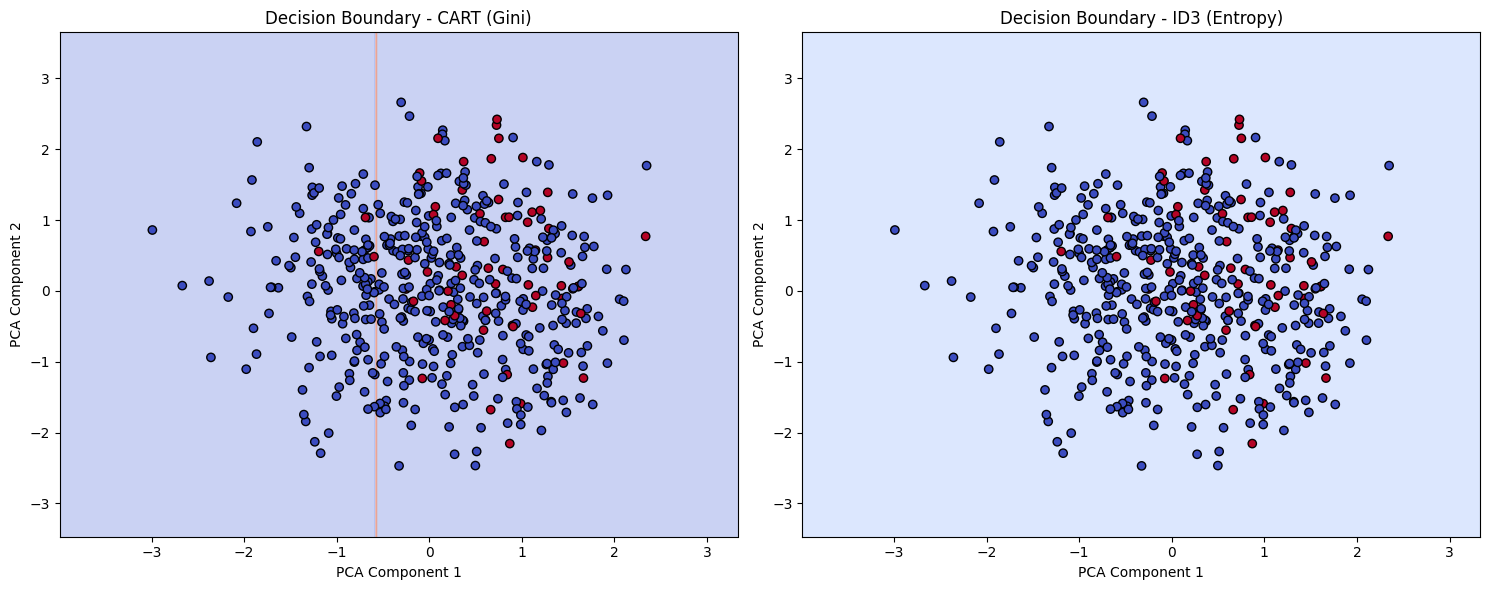

In [32]:
from sklearn.decomposition import PCA



pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)


cart_boundary = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_cart.max_depth,
    min_samples_split=best_cart.min_samples_split,
    random_state=42
)

cart_boundary.fit(
    X_train_pca,
    y_train
)



id3_boundary = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_id3.max_depth,
    min_samples_split=best_id3.min_samples_split,
    random_state=42
)

id3_boundary.fit(
    X_train_pca,
    y_train
)



x_min = X_test_pca[:,0].min() - 1

x_max = X_test_pca[:,0].max() + 1

y_min = X_test_pca[:,1].min() - 1

y_max = X_test_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)



cart_surface = cart_boundary.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

cart_surface = cart_surface.reshape(xx.shape)



id3_surface = id3_boundary.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

id3_surface = id3_surface.reshape(xx.shape)



fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,6)
)



ax[0].contourf(
    xx,
    yy,
    cart_surface,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

ax[0].scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test,
    cmap=plt.cm.coolwarm,
    edgecolors='black'
)

ax[0].set_title(
    "Decision Boundary - CART (Gini)"
)

ax[0].set_xlabel(
    "PCA Component 1"
)

ax[0].set_ylabel(
    "PCA Component 2"
)



ax[1].contourf(
    xx,
    yy,
    id3_surface,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

ax[1].scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test,
    cmap=plt.cm.coolwarm,
    edgecolors='black'
)

ax[1].set_title(
    "Decision Boundary - ID3 (Entropy)"
)

ax[1].set_xlabel(
    "PCA Component 1"
)

ax[1].set_ylabel(
    "PCA Component 2"
)

plt.tight_layout()

plt.show()

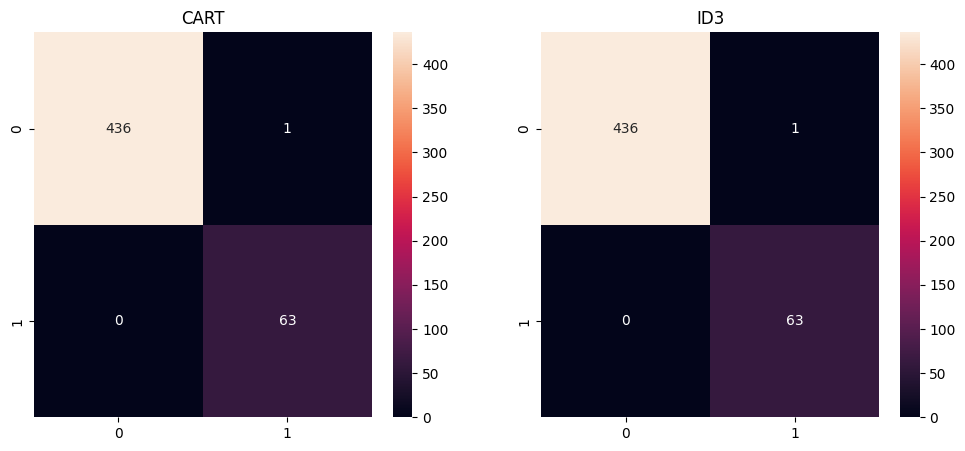

In [33]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test,cart_pred),
    annot=True,
    fmt="d",
    ax=ax[0]
)

ax[0].set_title("CART")

sns.heatmap(
    confusion_matrix(y_test,id3_pred),
    annot=True,
    fmt="d",
    ax=ax[1]
)

ax[1].set_title("ID3")

plt.show()

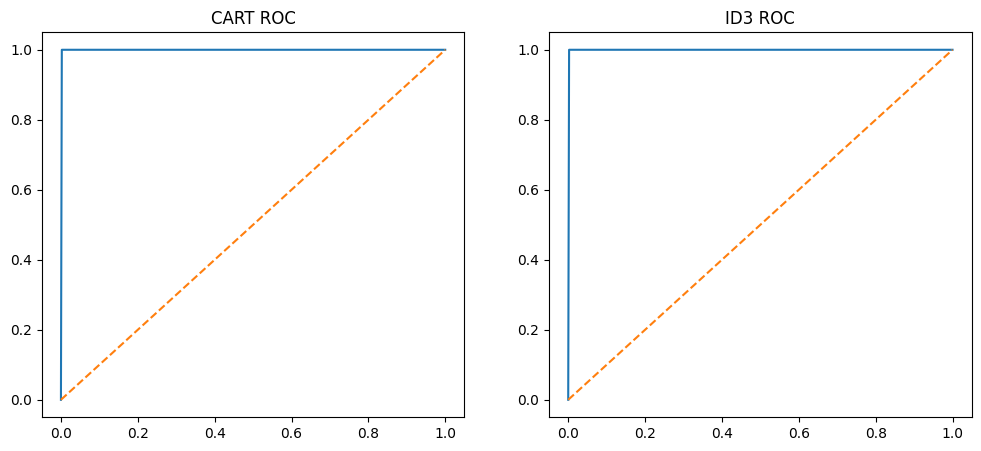

In [34]:
cart_fpr, cart_tpr, _ = roc_curve(y_test,cart_prob)

id3_fpr, id3_tpr, _ = roc_curve(y_test,id3_prob)

fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(cart_fpr,cart_tpr)
ax[0].plot([0,1],[0,1],"--")
ax[0].set_title("CART ROC")

ax[1].plot(id3_fpr,id3_tpr)
ax[1].plot([0,1],[0,1],"--")
ax[1].set_title("ID3 ROC")

plt.show()

In [35]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "CART":[
        accuracy_score(y_test,cart_pred),
        precision_score(y_test,cart_pred),
        recall_score(y_test,cart_pred),
        f1_score(y_test,cart_pred),
        roc_auc_score(y_test,cart_prob)
    ],

    "ID3":[
        accuracy_score(y_test,id3_pred),
        precision_score(y_test,id3_pred),
        recall_score(y_test,id3_pred),
        f1_score(y_test,id3_pred),
        roc_auc_score(y_test,id3_prob)
    ]
})

metrics

,Metric,CART,ID3
0,Accuracy,0.998000,0.998000
1,Precision,0.984375,0.984375
2,Recall,1.000000,1.000000
3,F1 Score,0.992126,0.992126
4,AUC,0.998856,0.998856


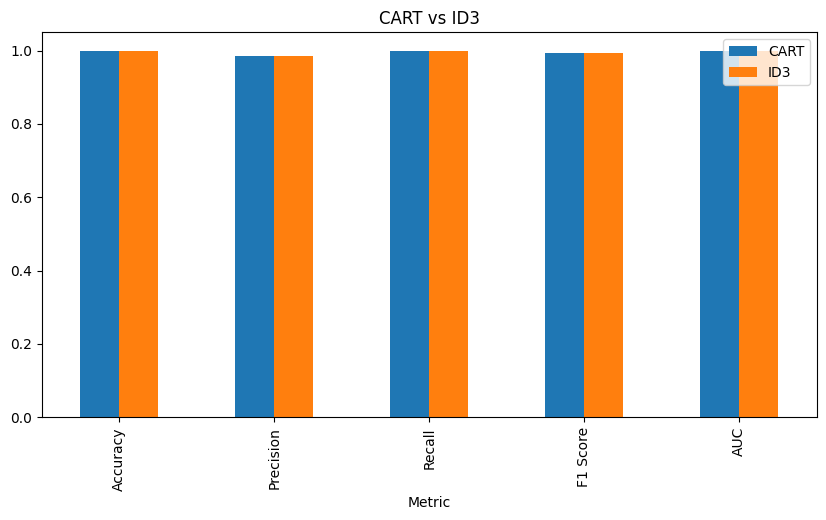

In [36]:
metrics.set_index("Metric").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("CART vs ID3")

plt.show()

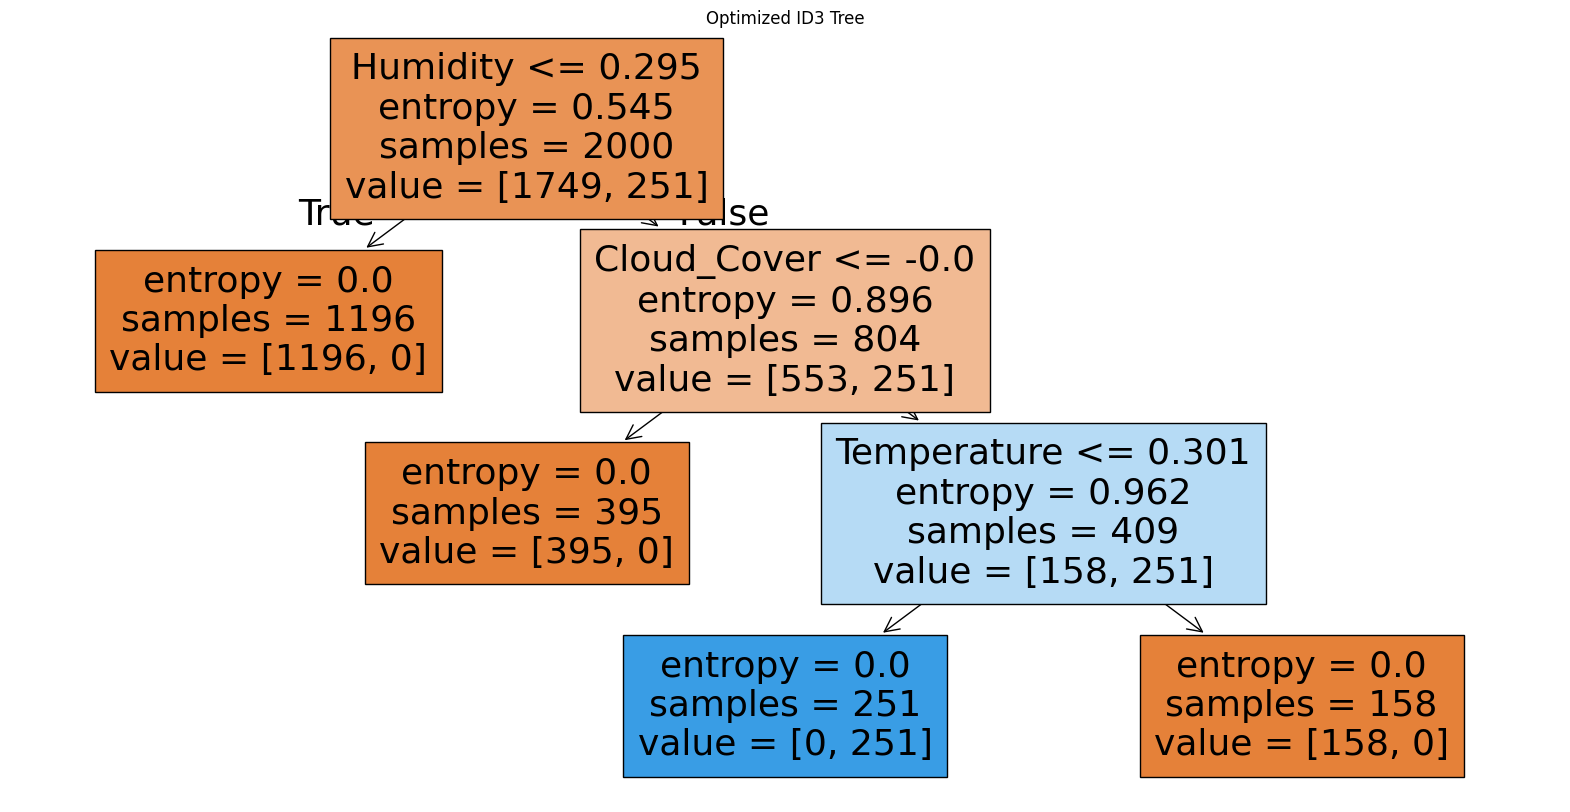

In [37]:
plt.figure(figsize=(20,10))

plot_tree(
    best_id3,
    feature_names=X.columns,
    filled=True
)

plt.title("Optimized ID3 Tree")

plt.show()

In [38]:
print("CART Accuracy :",
      accuracy_score(y_test,cart_pred))

print("ID3 Accuracy :",
      accuracy_score(y_test,id3_pred))

CART Accuracy : 0.998
ID3 Accuracy : 0.998
